Columns: ['Wavelength', 'Diatom_Ptricornutum', 'Diatom_Csimplex', 'Chlamydomonas_Cpriscuii', 'Chlamydomonas_Creindhardtii', 'Dinoflagellate_Symbiodiniumsp', 'Dinoflagellate_Smicroadriaticum', 'Dinoflagellate_Dtrenchii', 'Dinoflagellate_Cgoreaui', 'Cyanobacteria_Synechosystis']
   Wavelength  Diatom_Ptricornutum  Diatom_Csimplex  Chlamydomonas_Cpriscuii  \
0         800                  0.0              0.0                      0.0   
1         799                  0.0              0.0                      0.0   
2         798                  0.0              0.0                      0.0   
3         797                  0.0              0.0                      0.0   
4         796                  0.0              0.0                      0.0   

   Chlamydomonas_Creindhardtii  Dinoflagellate_Symbiodiniumsp  \
0                          0.0                      -0.000045   
1                          0.0                       0.004540   
2                          0.0                

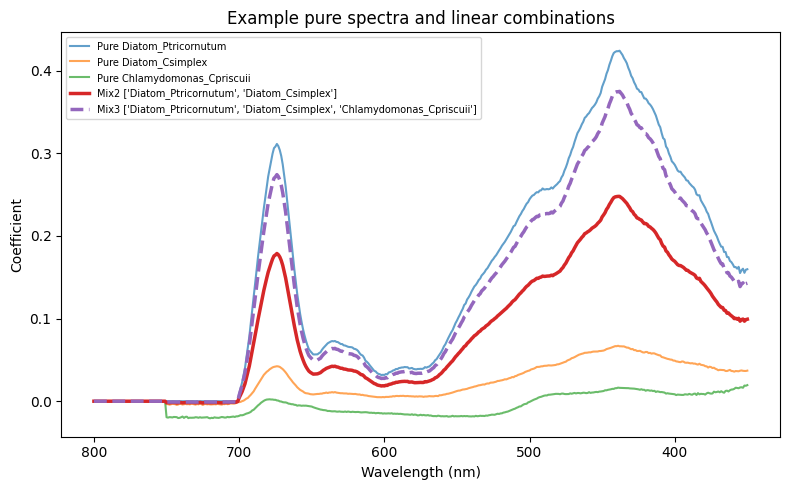

PyTorch version: 2.8.0
Using device: mps


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from linear_combination import generate_mixture_spectra
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

# Preferably use a GPU instead of CPU
print(f"PyTorch version: {torch.__version__}")
# --- Auto-detect GPU (CUDA or Apple MPS) — falls back to CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

In [2]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:].to_numpy().T

In [3]:
def data_creation(N_training_, N_validation_, noise_level_, abs_spectra_):
    # set seed for reproduction purposes
    N_species = len(abs_spectra_)
    N_wavelengths = len(wavelength)
    X = torch.zeros(N_species, (N_training_ + N_validation_), N_wavelengths)
    y = torch.zeros(N_species, (N_training_ + N_validation_), dtype=torch.long) # class needs integer 

    for specie_index, spectra in enumerate(abs_spectra_):
        data = torch.zeros(N_training_ + N_validation_, N_wavelengths)
        
        for i in range(N_training_ + N_validation_):
            data[i, :] = torch.tensor(spectra, dtype=torch.float32) + noise_level_ * torch.randn(N_wavelengths)

        X[specie_index] = data
        y[specie_index] = torch.zeros(N_training_ + N_validation_, dtype=torch.long) + int(specie_index)

    # shuffle first
    perm = torch.randperm(X.shape[1])
    X, y = X[:, perm, :], y[:, perm]
    
    # compute stats on training portion only
    mean = X[:, :N_training_, :].mean(dim=(1,2), keepdim=True)
    std  = X[:, :N_training_, :].std(dim=(1,2),  keepdim=True) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets into training and validation
    X_train_, y_train_ = X_norm[:, :N_training_, :], y[:, :N_training_]
    X_val_,   y_val_   = X_norm[:, N_training_:, :], y[:, N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [ ]:
noise_level = .1
X_train, y_train, X_val, y_val = data_creation(1000, 200, noise_level, abs_spectra)

N_species, N_train, N_wave = X_train.shape

# Sample dimensions (N_species, N_train, N_wave) ==> (N_samples_total, N_wave)
X_pure = X_train.reshape(-1, N_wave).numpy()

# Sample dimensions (N_species, N_train) ==> (N_samples_total)
y_pure = y_train.reshape(-1).numpy()

(9000, 451)


In [5]:
# PCA implementation
pca = PCA(n_components=4, random_state=0)   # We can play around with number of PCA components :)

# All pure spectra in PCA space
X_pure_pca = pca.fit_transform(X_pure)

# Gaussian Mixture Model implementation
gmm = GaussianMixture(
    n_components=N_species,
    n_init=50,
    max_iter=500,
    random_state=0
)

gmm.fit(X_pure_pca)

# Mapping sklearn components to species labels
resp_pure = gmm.predict_proba(X_pure_pca)   # Shape: (N_samples, N_species)
component_to_species = {}
for k in range(N_species):
    # Find all samples whose most likely component is k
    idx = np.argmax(resp_pure, axis=1) == k

    # The model can't tell which species is best (bad)
    if idx.sum() == 0:
        component_to_species[k] = None

    else:
        labels = y_pure[idx]
        values, counts = np.unique(labels, return_counts=True)

        # Pick the majority species among those samples (for example, k=3 is mapped to species 0)
        component_to_species[k] = int(values[np.argmax(counts)])
    
print(component_to_species)

/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jochem1411/Library/CloudStorage/OneD

{0: 8, 1: 3, 2: 6, 3: 2, 4: 5, 5: 0, 6: 4, 7: 7, 8: 1}


/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Yea

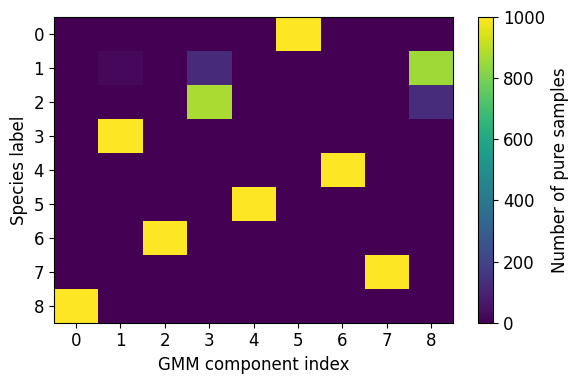

In [6]:
comp_hat = np.argmax(resp_pure, axis=1)
species_ids = np.unique(y_pure)
component_ids = np.arange(resp_pure.shape[1])

counts = np.zeros((len(species_ids), len(component_ids)), dtype=int)

for i, s in enumerate(species_ids):
    for j, k in enumerate(component_ids):
        counts[i, j] = np.sum((y_pure == s) & (comp_hat == k))

plt.figure(figsize=(6, 4))
im = plt.imshow(counts, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Number of pure samples")

plt.xticks(ticks=np.arange(len(component_ids)), labels=component_ids)
plt.yticks(ticks=np.arange(len(species_ids)), labels=species_ids)

plt.xlabel("GMM component index")
plt.ylabel("Species label")
plt.tight_layout()
plt.show()

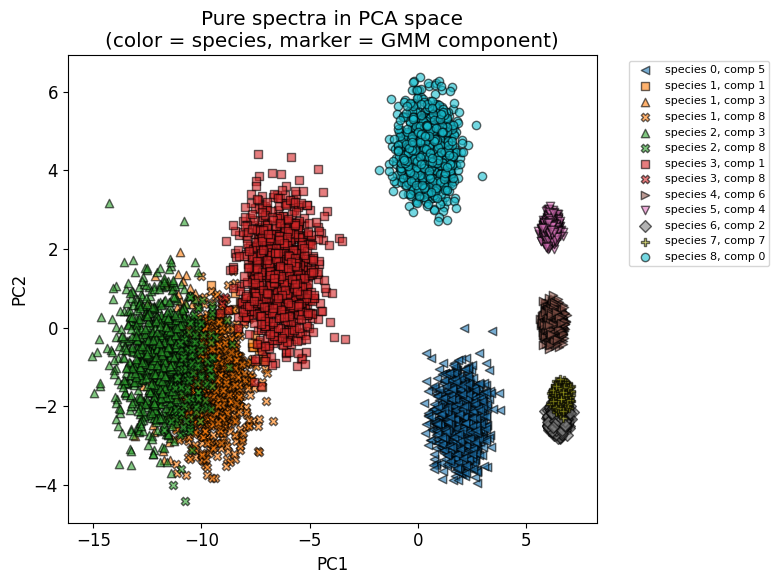

In [7]:
pc1 = X_pure_pca[:, 0]
pc2 = X_pure_pca[:, 1]

# For each sample: component with max responsibility
comp_hat = np.argmax(resp_pure, axis=1)

n_species = len(np.unique(y_pure))
n_components = resp_pure.shape[1]

plt.figure(figsize=(8, 6))

# Color by true species, marker style by component
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X']
colors = plt.cm.tab10(np.linspace(0, 1, n_species))

for s in range(n_species):
    for k in range(n_components):
        mask = (y_pure == s) & (comp_hat == k)
        if not np.any(mask):
            continue
        label = f"species {s}, comp {k}"
        plt.scatter(
            pc1[mask], pc2[mask],
            c=[colors[s]],
            marker=markers[k % len(markers)],
            edgecolor='k',
            alpha=0.6,
            label=label
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pure spectra in PCA space\n(color = species, marker = GMM component)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Small explanation on mapping for intuition
After training (`gmm.fit(X_pure_pca)`), `sklearn` gives you component indexed as `0, 1, 2, ...`, but it does not know which GMM component corresponds to which species. Therefore, we need to map these components to species labels (hence why I choose to use `n_components=N_species` in the `GaussianMixture` class). As an example: resp_pure[i, k] is approximately the probability that sample i belongs to component k. Consequently, each (mixed) sample must sum to 1.

$$
\sum_{k=0}^{N_{\text{species}} - 1} \text{resp\_pure}(i, k) = 1
$$

Then, the code looks among the species component k likes best. It asks itself which species occurs most often (majority species); that species belongs to that component!

0.9716666666666667
Validation Accuracy: 97.17%


/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


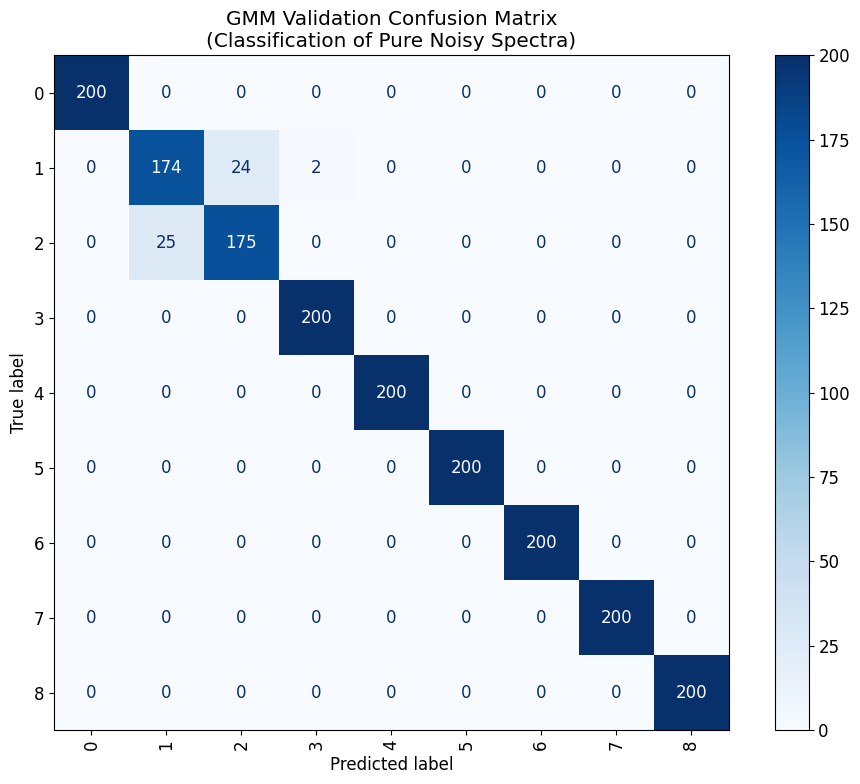

In [ ]:
N_species_val, N_val_samples, N_wave_val = X_val.shape
X_val_pure = X_val.reshape(-1, N_wave_val).numpy()
y_val_pure = y_val.reshape(-1).numpy()

# Transform validation data into the fitted PCA space
X_val_pca = pca.transform(X_val_pure)

# Get GMM predictions
val_components = gmm.predict(X_val_pca)

# Map the GMM components back to species labels
y_val_pred = np.array([component_to_species.get(c, -1) for c in val_components])

# Calculate validation accuracy
valid_mask = y_val_pred != -1
accuracy = accuracy_score(y_val_pure[valid_mask], y_val_pred[valid_mask])
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Plot a confusion matrix
cm = confusion_matrix(y_val_pure[valid_mask], y_val_pred[valid_mask])

labels = np.unique(y_val_pure)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

plt.title("GMM Validation Confusion Matrix\n(Classification of Pure Noisy Spectra)")
plt.tight_layout()
plt.show()